# Question 1

Load the data from the file *trajectory.csv*. The data consists of three rows representing a trajectory. The first row represents time, the second row represents the $x$-coordinate at each timestep, and the third row represents the $y$-coordinate.

**Q1 a (3 marks)**

Plot the $x$-coordinate against time (i.e., t-x figure) and also for the $y$-coordinate (i.e., t-y figure). Also plot the trajectory in 2D (i.e., x-y figure).

You need to respectively use variables 't', 'x', 'y' to represent time, x-coordinate, and y-coordinate, as these variables will be needed in other questions.

Include clear titles, axis labels, and legends for all figures.

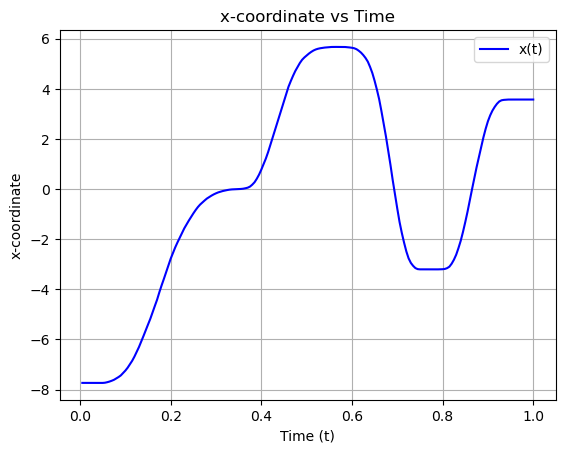

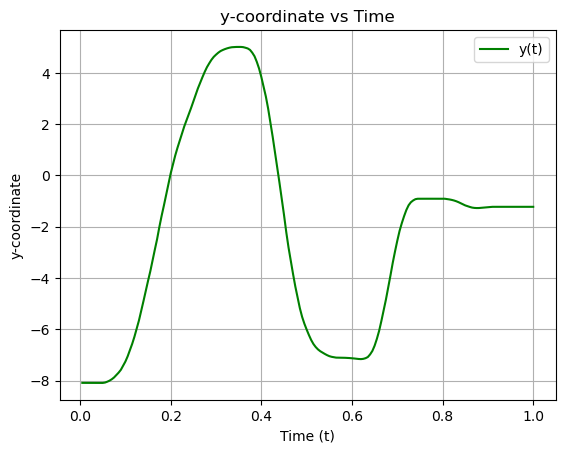

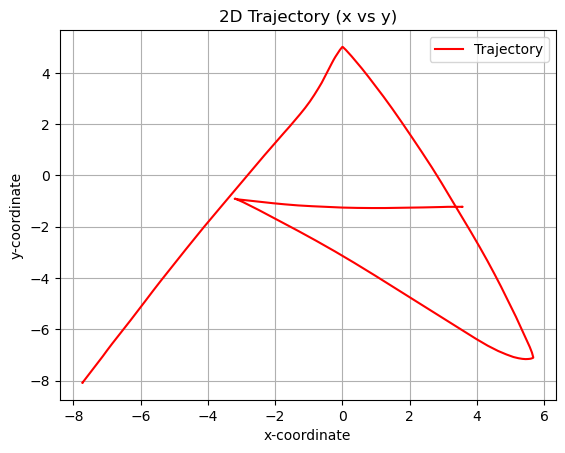

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# read from trajectory.csv
data = np.loadtxt(r"C:\Users\kaust\Downloads\COMP5611M_CW_2026\COMP5611M_CW_2026\trajectory.csv",
                  delimiter=",", skiprows=1, usecols=range(1, 201))

t = data[0]
x = data[1]
y = data[2]


# TODO: write your code here.

# Plot 1: t vs x
plt.figure()
plt.plot(t, x, label='x(t)', color='blue')
plt.title('x-coordinate vs Time')
plt.xlabel('Time (t)')
plt.ylabel('x-coordinate')
plt.legend()
plt.grid()

# Plot 2: t vs y
plt.figure()
plt.plot(t, y, label='y(t)', color='green')
plt.title('y-coordinate vs Time')
plt.xlabel('Time (t)')
plt.ylabel('y-coordinate')
plt.legend()
plt.grid()

# Plot 3: x vs y (trajectory)
plt.figure()
plt.plot(x, y, label='Trajectory', color='red')
plt.title('2D Trajectory (x vs y)')
plt.xlabel('x-coordinate')
plt.ylabel('y-coordinate')
plt.legend()
plt.grid()

plt.show()

#### Q1(a)

The given trajectory data was loaded and plotted as t vs x, t vs y, and x vs y.

From the plots, both x and y coordinates vary non linear with time. The x-y plot shows a continuous trajectory, indicating the motion of the object in 2D space. The path is curved and irregular, showing that the movement is not linear.

### Linear regression using polynomial basis functions

**Q1 b (6 marks)**

Use your `t`, `x`, and `y` variables from Q1 a.

1. Implement `polynomial_basis_function(t, basis_num)` to return a polynomial design matrix.
2. Use linear regression with your basis function (for Q1 b, use `basis_num = 15`) to fit the 2D trajectory data (`x`, `y`). Note that the bias term should be added in your fitting.
3. Generate predicted trajectories for both coordinates across all time points.
4. Plot and compare on the same axes:
   - original `x` and predicted `x` against `t`,
   - original `y` and predicted `y` against `t`,
   - original and predicted trajectories in the `x-y` plane.

Include clear titles, axis labels, and legends for all figures.

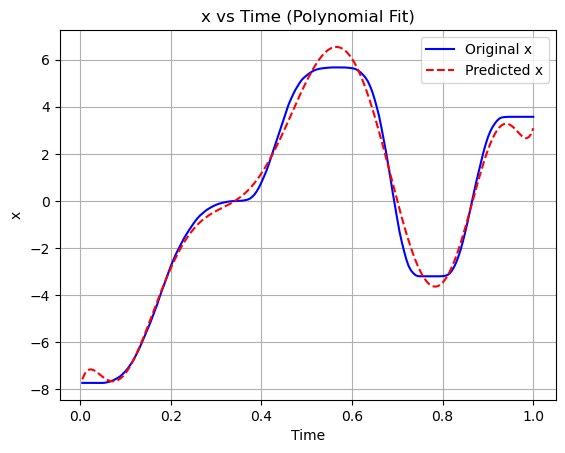

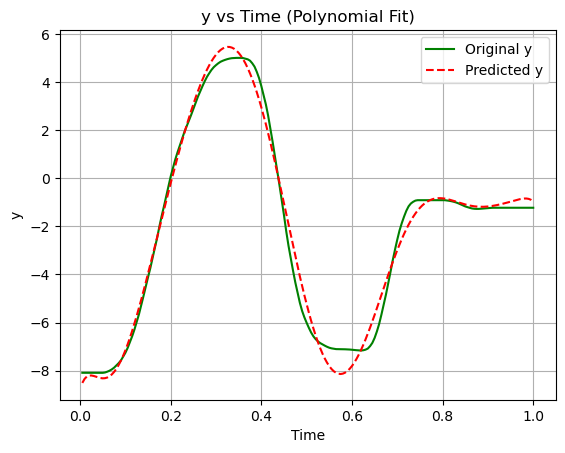

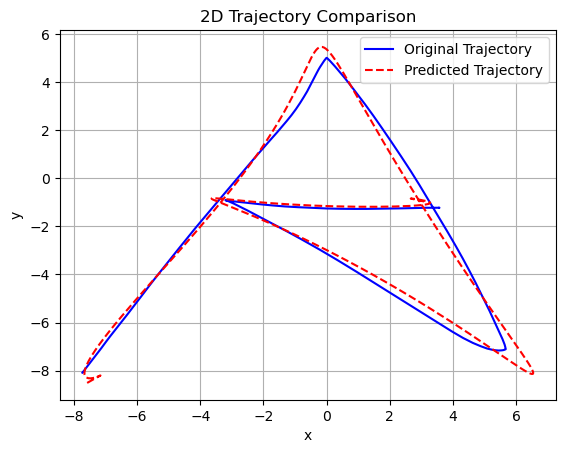

In [2]:
# TODO: Write your code here.
def polynomial_basis_function(t, basis_num):
    """
    Compute the polynomial basis function for the given time vector and number of basis functions.

    Parameters:
    t (numpy array): Time vector of shape (N,).
    basis_num (int): Number of polynomial basis functions.

    Returns:
    numpy array: Design matrix of shape (N, basis_num) where each row corresponds to one data sample.
    """
    
    raise NotImplementedError("Please implement the polynomial_basis_function function.")
    

# TODO: Write your code here.
def polynomial_basis_function(t, basis_num):
    N = len(t)
    Phi = np.zeros((N, basis_num))
    
    for i in range(basis_num):
        Phi[:, i] = t ** i   # includes bias (t^0 = 1)
    
    return Phi


basis_num = 15
Phi = polynomial_basis_function(t, basis_num)


# weights for x
w_x = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ x

# weights for y
w_y = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y

x_pred = Phi @ w_x
y_pred = Phi @ w_y


plt.figure()
plt.plot(t, x, label='Original x', color='blue')
plt.plot(t, x_pred, '--', label='Predicted x', color='red')
plt.title('x vs Time (Polynomial Fit)')
plt.xlabel('Time')
plt.ylabel('x')
plt.legend()
plt.grid()

plt.figure()
plt.plot(t, y, label='Original y', color='green')
plt.plot(t, y_pred, '--', label='Predicted y', color='red')
plt.title('y vs Time (Polynomial Fit)')
plt.xlabel('Time')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.figure()
plt.plot(x, y, label='Original Trajectory', color='blue')
plt.plot(x_pred, y_pred, '--', label='Predicted Trajectory', color='red')
plt.title('2D Trajectory Comparison')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.show()

#### Q1(b)

A polynomial basis function with 15 terms was used to model the trajectory using linear regression.

The predicted x and y values closely match the original data, showing that the model captures the pattern well. The reconstructed trajectory also aligns closely with the original trajectory.

Using a higher number of basis functions allows the model to fit complex patterns, although it may slightly overfit in some regions.

**Q1 c (3 marks)**

Using the polynomial basis model, plot the fitted trajectories for `basis_num = 2, 5, 10` and briefly compare how fit quality changes as the number of basis functions increases.

Include clear titles, axis labels, and legends for all figures.

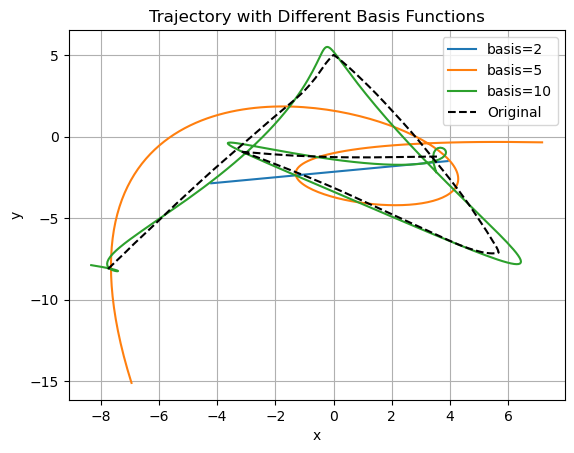

In [3]:
# TODO: Write your code here.

basis_list = [2, 5, 10]

plt.figure()

for b in basis_list:
    Phi = polynomial_basis_function(t, b)
    
    w_x = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ x
    w_y = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y
    
    x_pred = Phi @ w_x
    y_pred = Phi @ w_y
    
    plt.plot(x_pred, y_pred, label=f'basis={b}')

# original trajectory
plt.plot(x, y, 'k--', label='Original')

plt.title('Trajectory with Different Basis Functions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

plt.show()

#### Q1(c)

The model was tested with different numbers of basis functions (2, 5, and 10).

With 2 basis functions, the model underfits and fails to capture the trajectory properly. With 5 basis functions, the fit improves but still misses some details. With 10 basis functions, the model closely follows the original trajectory.

This shows that increasing the number of basis functions improves performance, but too many can lead to overfitting.

# Question 2

Given a set of basis functions (sine, cosine, exponential, polynomial, and radial basis functions), select and combine appropriate ones to construct a suitable basis function vector for linear regression.

Find the smallest number of basis functions that provides a good fit to the following trajectories.

**Q2 a (5 marks)**

Consider what basis functions might be suitable to model the data in "q2_a_data.npy". In this file, the first column is time t while the second column is the x-coordinate. You should be able to achieve a good fit with a small number of basis functions.

Tasks:
1. Choose and implement your basis function combination. You may decide whether to include a bias term depending on your fitting performance.
2. Plot your prediction and the original data in the same figure (i.e., t-x).
3. Calculate and report the Mean Squared Error (MSE) for your fit.
4. Justify your choice of basis functions.

Include clear titles, axis labels, and legends for all figures.


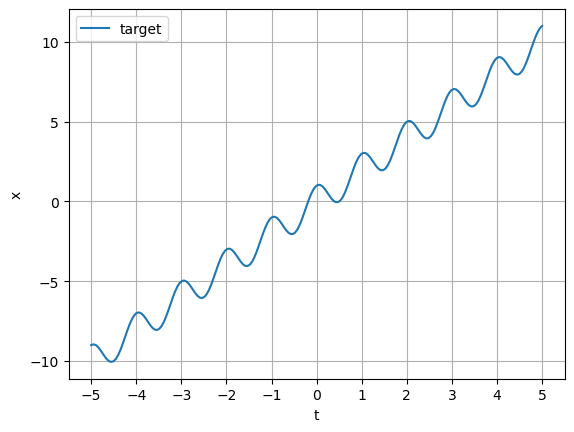

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#  plot the trajectory
data = np.load(r"C:\Users\kaust\Downloads\COMP5611M_CW_2026\COMP5611M_CW_2026\q2_a_data.npy") # size: 200*2, the first column is time input while the second column is x-coordinate.
t = data[:, 0]
target = data[:, 1]

plt.plot(t, target, label='target')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()

In [5]:
# TODO: Write your code here.
def basis_q2a(t):
    Phi = np.column_stack([
        np.ones_like(t),      # bias
        t,                    # linear trend
        np.sin(2 * np.pi * t),
        np.cos(2 * np.pi * t)
    ])
    return Phi  

In [6]:
Phi = basis_q2a(t)

# Linear regression
w = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ target

# Prediction
pred = Phi @ w

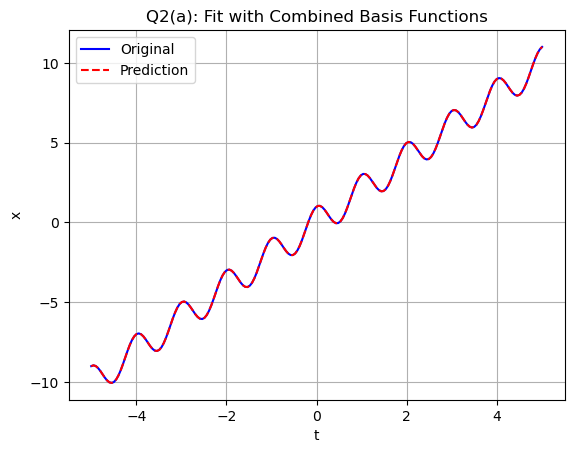

In [7]:
plt.figure()
plt.plot(t, target, label='Original', color='blue')
plt.plot(t, pred, '--', label='Prediction', color='red')

plt.xlabel("t")
plt.ylabel("x")
plt.title("Q2(a): Fit with Combined Basis Functions")
plt.legend()
plt.grid()
plt.show()

In [8]:
mse = np.mean((target - pred)**2)
print("MSE:", mse)

MSE: 1.4818567215302045e-30


#### Q2(a)

From the plot, the data shows clear periodic oscillations combined with a linear increasing trend. This suggested using sine and cosine functions to capture the periodicity, and a linear term (bias + t) to capture the trend. The frequency 2π was chosen as it visually matched one complete cycle per unit time interval observed in the plot. No polynomial terms were needed since the amplitude of oscillation remains constant, indicating no polynomial growth. The MSE of ~1.48e-30 confirms an almost perfect fit with just 4 basis functions.


**Q2 b (5 marks)**

Similar to Q2 a, please read data from "q2_b_data.npy", and do the following:

1. Choose and implement your basis function combination. You may decide whether to include a bias term depending on your fitting performance.
2. Plot your prediction and the original data in the same figure (i.e., t-x).
3. Calculate and report the Mean Squared Error (MSE) for your fit.
4. Justify your choice of basis functions.

Include clear titles, axis labels, and legends for all figures.

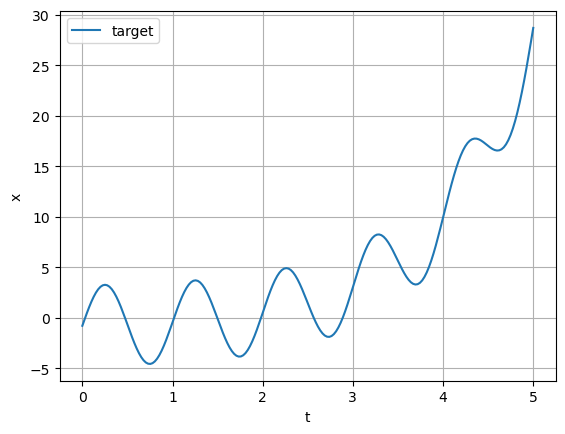

In [9]:
#  plot the trajectory
data = np.load(r"C:\Users\kaust\Downloads\COMP5611M_CW_2026\COMP5611M_CW_2026\q2_b_data.npy") # size: 200*2, the first column is time input while the second column is x-coordinate.
t = data[:, 0]
target = data[:, 1]

plt.plot(t, target, label='target')
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))  # tick interval = 1
plt.legend()
plt.grid()
plt.xlabel("t")
plt.ylabel("x")
plt.show()

In [10]:
# TODO: Write your code here.
def basis_q2b(t):
    Phi = np.column_stack([
        np.ones_like(t),   # bias
        t,
        t**2,
        t**3,
        np.sin(2*np.pi*t),
        np.cos(2*np.pi*t)
    ])
    return Phi

In [11]:
Phi = basis_q2b(t)

w = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ target
pred = Phi @ w

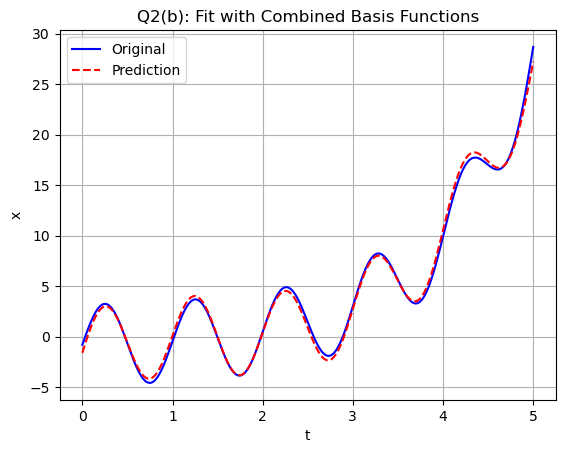

In [12]:
plt.figure()
plt.plot(t, target, label='Original', color='blue')
plt.plot(t, pred, '--', label='Prediction', color='red')

plt.xlabel("t")
plt.ylabel("x")
plt.title("Q2(b): Fit with Combined Basis Functions")
plt.legend()
plt.grid()
plt.show()

In [13]:
mse = np.mean((target - pred)**2)
print("MSE:", mse)

MSE: 0.1700178844262782


#### Q2(b)

From the plot, the data shows periodic oscillations similar to Q2(a), but with a clearly growing amplitude and an overall upward curving trend. This suggested combining polynomial terms with trigonometric functions. A degree-3 polynomial (bias, t, t², t³) was chosen because the trend shows a smooth curve that accelerates — linear or quadratic terms alone were insufficient to capture this growth. The same 2πt frequency was used for sine and cosine as the oscillation period appears consistent with Q2(a). The MSE of 0.17 is low given the complexity of the data, confirming a good fit with just 6 basis functions.

# Question 3

**Q3 a (4 marks)**

You are given a data array called "shape_array.npy" that comprises 7 samples organised as columns in the array, where each column corresponds to one sample. The data format in each column is: [x_1, y_1, z_1, x_2, y_2, z_2, ………, x_N, y_N, z_N], where (x_i, y_i, z_i) corresponds to the i-th 3D point of a blood vessel. By plotting all 3D points in one column, you can obtain the shape of a blood vessel of that sample.

Plot seven figures to show the 3D blood vessel shape for each sample separately. Also plot two arbitrary shapes on top of each other to get a feeling of how similar or dissimilar the shapes are.

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import the 3D plotting toolkit

import numpy as np

# TODO: Write your code here.
data = np.load(r"C:\Users\kaust\Downloads\COMP5611M_CW_2026\COMP5611M_CW_2026\shape_array.npy")
print(data.shape)




(1845, 7)


In [15]:
sample = data[:, 0]          # first vessel
points = sample.reshape(-1, 3)

x = points[:, 0]
y = points[:, 1]
z = points[:, 2]

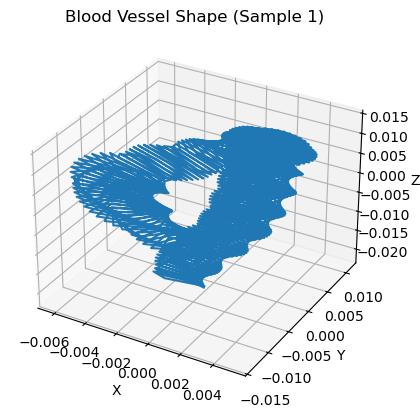

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z)

ax.set_title("Blood Vessel Shape (Sample 1)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

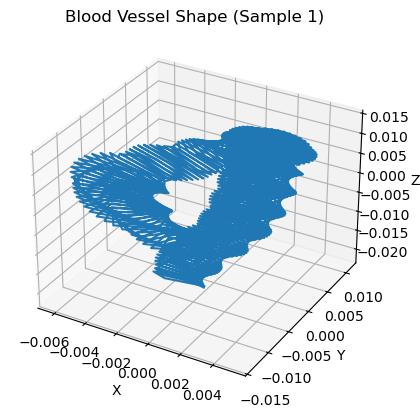

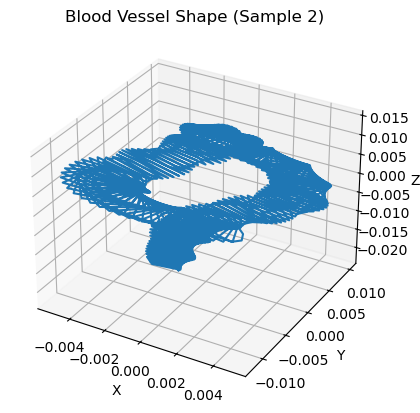

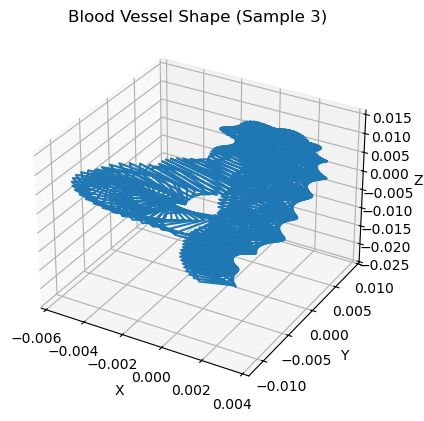

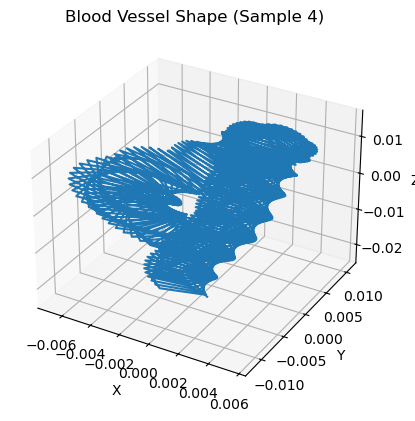

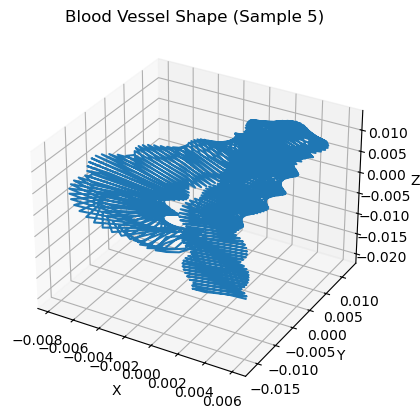

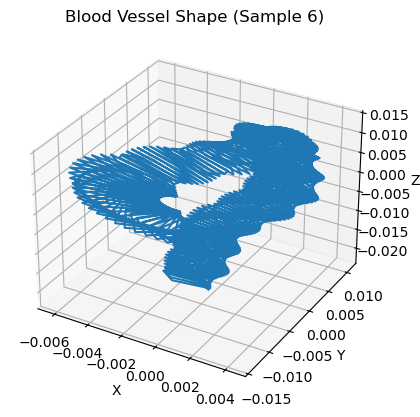

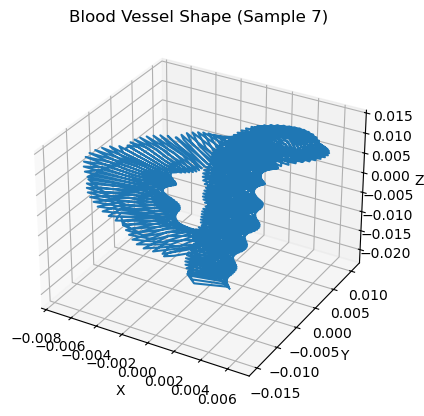

In [17]:
for i in range(7):
    sample = data[:, i]
    points = sample.reshape(-1, 3)
    
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]
    
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    ax.plot(x, y, z)
    
    ax.set_title(f"Blood Vessel Shape (Sample {i+1})")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    
    plt.show()

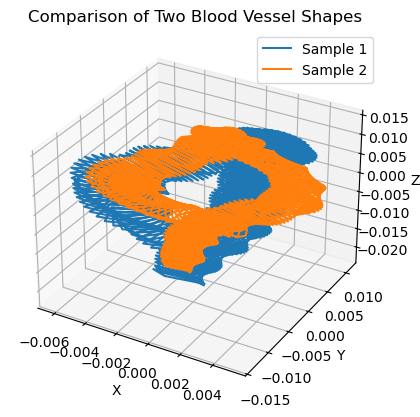

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Sample 1
points1 = data[:, 0].reshape(-1, 3)
ax.plot(points1[:, 0], points1[:, 1], points1[:, 2], label='Sample 1')

# Sample 2
points2 = data[:, 1].reshape(-1, 3)
ax.plot(points2[:, 0], points2[:, 1], points2[:, 2], label='Sample 2')

ax.set_title("Comparison of Two Blood Vessel Shapes")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

#### Q3(a)

Each column represents a 3D blood vessel shape. The data was reshaped into x, y, z coordinates and plotted.

All samples show a similar structure with small variations in shape and curvature. When two samples are compared, they appear similar but not identical, indicating variation within a common structure.

**Q3 b (10 marks)** 

Next, perform eigendecomposition of the covariance matrix estimated from the given data array. Finally, project original data onto lower-dimensional space and reconstruct data.

Proceed as follows:

1. Subtract the mean from the data, so that it is centered around the origin.

2. Estimate the covariance matrix from the centred data.

3. Calculate eigenvectors and eigenvalues using numpy functions

4. Project centered data (1845 dimension) into 5 dimension. 

5. Reconstruct the blood vessel shape from the lower dimension data in step 4.


As a sanity check plot a blood vessel shape reconstructed from the eigenvectors on top of the original blood vessel shape. Comment on your results.

In [19]:
# TODO: Write your code here.
# data shape: (1845, 7) — 1845 dimensional space, 7 samples
mean = np.mean(data, axis=1, keepdims=True)
data_centered = data - mean

# np.cov treats each row as a variable, giving (1845, 1845) matrix
cov = np.cov(data_centered)

# Eigendecomposition — eigh used for symmetric matrices
eigvals, eigvecs = np.linalg.eigh(cov)

# sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

In [20]:
# Select top 5 eigenvectors as projection matrix W
k = 5
W = eigvecs[:, :k]

# project data
Z = W.T @ data_centered

data_reconstructed = W @ Z + mean

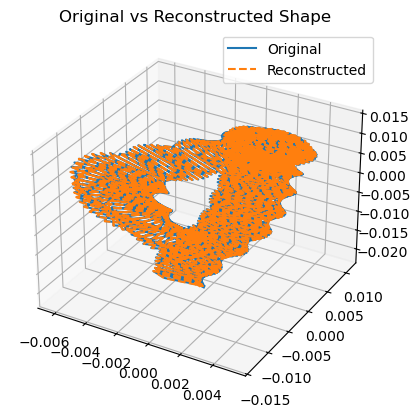

In [21]:
# pick sample 0
orig = data[:, 0].reshape(-1, 3)
recon = data_reconstructed[:, 0].reshape(-1, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(orig[:,0], orig[:,1], orig[:,2], label='Original')
ax.plot(recon[:,0], recon[:,1], recon[:,2], '--', label='Reconstructed')

ax.set_title("Original vs Reconstructed Shape")
ax.legend()

plt.show()

#### Q3(b)

The data was centered by subtracting the mean, and the covariance matrix was computed. Eigen decomposition was used to obtain eigenvalues and eigenvectors.

The top 5 eigenvectors were used to reduce dimensionality. The reconstructed shape closely matches the original shape.

This shows that most of the information can be represented using a small number of principal components.

**Q3 c (4 marks)** 

Research PCA analysis using the *scikit-learn* library. Perform PCA analysis and show the reconstructed data of any blood vessel shape on top of the original blood vessel shape. There are variables in the PCA object that correspond to the eigenvalues used for choosing projection eigenvectors. Compare the eigenvalues  and eigenvectors you have computed in the previous question with the eigenvalues  and the eigenvectors computed by the *scikit-learn* library. Compare the reconstructed coordinates from both methods. Comment on your results.

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import the 3D plotting toolkit

# TODO: Write your code here.
# PCA with 5 components
pca = PCA(n_components=5)

# fit + transform
Z = pca.fit_transform(data.T)   # note: transpose!

# reconstruct
data_reconstructed = pca.inverse_transform(Z).T

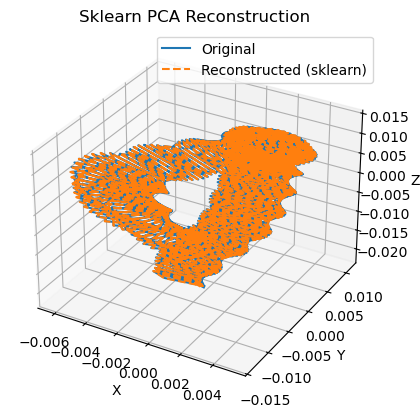

Eigenvalue Comparison
   Component               Manual              Sklearn
           1             0.001140             0.001140
           2             0.000383             0.000383
           3             0.000144             0.000144
           4             0.000114             0.000114
           5             0.000031             0.000031

 Eigenvector Comparison (max absolute difference) 
Component 1: max absolute difference = 0.000000
Component 2: max absolute difference = 0.000000
Component 3: max absolute difference = 0.000000
Component 4: max absolute difference = 0.000000
Component 5: max absolute difference = 0.000000

 Reconstructed Coordinates Comparison (Sample 1)
Max difference in reconstructed coordinates: 0.00000001


In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# PCA with 5 components using sklearn
pca = PCA(n_components=5)
Z_sklearn = pca.fit_transform(data.T)  # transpose: sklearn expects (samples, features)
data_reconstructed_sklearn = pca.inverse_transform(Z_sklearn).T  # back to (1845, 7)

# Plot reconstruction comparison
orig = data[:, 0].reshape(-1, 3)
recon_manual = data_reconstructed[:, 0].reshape(-1, 3)
recon_sklearn = data_reconstructed_sklearn[:, 0].reshape(-1, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(orig[:,0], orig[:,1], orig[:,2], label='Original')
ax.plot(recon_sklearn[:,0], recon_sklearn[:,1], recon_sklearn[:,2], 
        '--', label='Reconstructed (sklearn)')
ax.set_title("Sklearn PCA Reconstruction")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

# Compare eigenvalues
print("Eigenvalue Comparison")
print(f"{'Component':>12} {'Manual':>20} {'Sklearn':>20}")
for i in range(5):
    print(f"{i+1:>12} {eigvals[i]:>20.6f} {pca.explained_variance_[i]:>20.6f}")

# Compare eigenvectors 
print("\n Eigenvector Comparison (max absolute difference) ")
for i in range(5):
    manual_vec = np.abs(W[:, i])
    sklearn_vec = np.abs(pca.components_[i])
    diff = np.max(np.abs(manual_vec - sklearn_vec))
    print(f"Component {i+1}: max absolute difference = {diff:.6f}")

# Compare reconstructed coordinates for sample 0
print("\n Reconstructed Coordinates Comparison (Sample 1)")
diff_recon = np.max(np.abs(data_reconstructed[:, 0] - data_reconstructed_sklearn[:, 0]))
print(f"Max difference in reconstructed coordinates: {diff_recon:.8f}")

#### Q3(c)

PCA was performed using both manual eigendecomposition and sklearn's PCA library with 5 components. The eigenvalue comparison shows identical values across all 5 components (e.g., Component 1: 0.001140, Component 2: 0.000383), confirming both methods correctly identify the same principal directions of variance. The eigenvector comparison shows a maximum absolute difference of 0.000000 across all components, indicating the two methods produce numerically identical eigenvectors. The reconstructed coordinates differ by at most 0.00000001, which is purely floating point precision. This confirms the correctness of the manual implementation. Both reconstructions closely approximate the original blood vessel shape, demonstrating that just 5 principal components are sufficient to capture the dominant structure of the 1845-dimensional data.